In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# DINOv3

**Paper:** [arXiv:2508.10104](https://arxiv.org/abs/2508.10104)  
**HuggingFace model:** [facebook/dinov3-vits16-pretrain-lvd1689m](https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m)  
**GitHub:** [facebookresearch/dinov3](https://github.com/facebookresearch/dinov3)  

> Developed by: **Meta AI**  
> Model type: Vision Transformer (ViT) with Axial RoPE positional encoding

This notebook walks through a **from-scratch JAX implementation** of DINOv3, linking each code block directly to the corresponding section of the paper.

---

## Overview

DINOv3 builds on the DINO self-supervised learning framework and pushes it to a new scale:

| Property          | DINOv2         | DINOv3                  |
|-------------------|----------------|-------------------------|
| Training data     | ~14M images    | 142M+ images (LVD-1689M)|
| Largest model     | ViT-L          | ViT-7B                  |
| Positional enc.   | Interpolated sin/cos | **Axial RoPE**    |
| Dense features    | Degrade w/ long training | Preserved via **Gram Anchoring** |
| Register tokens   | ✗              | 4 register tokens     |

The models can be used **without fine-tuning** for:
- Image classification (k-NN, logistic regression, linear probe)
- Image retrieval
- Depth estimation & semantic segmentation (linear layers)
- Video segmentation tracking
- Unsupervised object discovery

### Imports

In [ ]:
import json
from dataclasses import dataclass

import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import PIL.Image as Image
from safetensors.torch import load_file
from transformers import AutoTokenizer

### Load Weights

**Model Release:** The paper releases a family of models in safetensors format. The `ViT-S/16` variant used here has:
- **384-dimensional** hidden size
- **6 attention heads**
- **12 transformer layers**
- Pre-trained on **LVD-1689M** (142M curated images)

The weights are loaded from a `.safetensors` file — a safe, fast alternative to PyTorch `.bin` files.

**Setup:** Download the model weights and config from HuggingFace and place them at `models/dinov3/` relative to your workspace root

In [ ]:
HF_REPO_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"
LOCAL_DIR_PATH = "workspace/models/dinov3"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)
print(f"Downloaded repository path: {local_dir}")

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
IMAGE_PATH = f"{LOCAL_DIR_PATH}/cat.png"

checkpoint_path = WEIGHTS_PATH
hf_weights = load_file(checkpoint_path)

### Model Configuration

**Architecture (Paper 3.1):** DINOv3 uses a standard ViT backbone, but with several key modifications:

- **Axial RoPE** replaces absolute positional embeddings - this enables flexible resolution at inference without interpolation artifacts
- **Register tokens** (3.3): 4 extra learnable tokens appended after the `[CLS]` token. The paper shows these absorb "artifact" attention patterns in background patches, producing cleaner attention maps and better dense features
- **LayerScale** (from DeiT-III): per-layer learned scaling vectors stabilize training of deep ViTs
- **Query/Key/Value bias** flags: notably `key_bias=False`, following the paper's efficient attention design

Note the `rope_theta=100.0` — this controls the base frequency of rotary embeddings (lower = higher frequency = sensitive to finer spatial detail).

In [4]:
@dataclass
class DinoV3:
    patch_size: int = 16
    hidden_size: int = 384
    intermediate_size: int = 1536
    num_hidden_layers: int = 12
    num_attention_heads: int = 6
    hidden_act: str = "gelu"
    attention_dropout: float = 0.0
    initializer_range: float = 0.02
    layer_norm_eps: float = 1e-5
    rope_theta: float = 100.0
    image_size: int = 224
    num_channels: int = 3
    query_bias: bool = True
    key_bias: bool = False
    value_bias: bool = True
    proj_bias: bool = True
    mlp_bias: bool = True
    layerscale_value: float = 1.0
    drop_path_rate: float = 0.0
    use_gated_mlp: bool = False
    num_register_tokens: int = 4

config = DinoV3()

### Weight Extraction

**Implementation Detail:** DINOv3 weights are stored in HuggingFace naming conventions. Here we extract and transpose them into JAX-friendly shapes.
>
Key things to observe:
- `patch_embeddings.weight` is transposed from `(out, in, kH, kW)` → `(kH, kW, in, out)` for JAX's `conv_general_dilated`
- `k_proj` has **no bias** (matching `key_bias=False` in config)
- Each layer has **two LayerScale vectors** (`lambda1`, `lambda2`) — one for the attention branch, one for the MLP branch


In [5]:
def get_w(
    name: str,
    transpose: bool = False
) -> jax.Array:
    val = hf_weights.pop(name)
    w = jnp.array(val.float(), dtype=jnp.bfloat16)
    return w.T if transpose else w

layers = []
for i in range(config.num_hidden_layers):
    layer = {
        'attn': {
            'q_proj': {
                'weight': get_w(f'layer.{i}.attention.q_proj.weight', transpose=True),
                'bias': get_w(f'layer.{i}.attention.q_proj.bias') if config.query_bias else None
            },
            'k_proj': get_w(f'layer.{i}.attention.k_proj.weight', transpose=True),
            'v_proj': {
                'weight': get_w(f'layer.{i}.attention.v_proj.weight', transpose=True),
                'bias': get_w(f'layer.{i}.attention.v_proj.bias') if config.value_bias else None
            },
            'o_proj': {
                'weight': get_w(f'layer.{i}.attention.o_proj.weight', transpose=True),
                'bias': get_w(f'layer.{i}.attention.o_proj.bias') if config.proj_bias else None
            },
        },
        'layer_scale': [
            get_w(f'layer.{i}.layer_scale1.lambda1'),
            get_w(f'layer.{i}.layer_scale2.lambda1')
        ],
        'mlp': {
            'up_proj': {
                'weight': get_w(f'layer.{i}.mlp.up_proj.weight', transpose=True),
                'bias': get_w(f'layer.{i}.mlp.up_proj.bias')
            },
            'down_proj': {
                'weight': get_w(f'layer.{i}.mlp.down_proj.weight', transpose=True),
                'bias': get_w(f'layer.{i}.mlp.down_proj.bias')
            },
        },
        'norm': [{
            'weight': get_w(f'layer.{i}.norm1.weight'),
            'bias': get_w(f'layer.{i}.norm1.bias')
        }, {
            'weight': get_w(f'layer.{i}.norm2.weight'),
            'bias': get_w(f'layer.{i}.norm2.bias')
        }]
    }
    layers.append(layer)


m = {
    'embeddings': {
        'patch_embeddings': {
            'weight': get_w('embeddings.patch_embeddings.weight').transpose(2, 3, 1, 0),
            'bias': get_w('embeddings.patch_embeddings.bias'),
        },
        'cls_token': get_w('embeddings.cls_token'),
        'register_tokens': get_w('embeddings.register_tokens'),
    },
    'layers': layers,
    'norm': {
        'weight': get_w('norm.weight'),
        'bias': get_w('norm.bias')
    },
}


### Image Preprocessing

**Data Pipeline (Paper 4):** DINOv3 uses ImageNet-standard normalization:
- Mean: `[0.485, 0.456, 0.406]`
- Std: `[0.229, 0.224, 0.225]`

Images are resized to `224×224` with bilinear interpolation. At inference, the model can handle **any resolution** due to RoPE (no interpolation of positional embeddings needed) — but we use 224 here to match the pre-training resolution.

Output shape: `(1, 224, 224, 3)` — batch-first, channels-last (JAX convention).

In [6]:
def preprocess_dinov3(
    image_path: str,
    target_size: tuple[int, int] = (224, 224)
) -> jax.Array:
    img = Image.open(image_path).convert("RGB")

    img_resized = img.resize(
        (target_size[1], target_size[0]), 
        resample=Image.BILINEAR
    )
    
    x = jnp.array(np.array(img_resized), dtype=jnp.float32) / 255.0
    
    mean = jnp.array([0.485, 0.456, 0.406])
    std = jnp.array([0.229, 0.224, 0.225])
    x = (x - mean) / std
    
    x = x.astype(jnp.bfloat16)
    
    return x[None, ...]


### Patch Embeddings + Register Tokens

**Patch Embedding (Paper 3.1):** A 16×16 strided convolution projects each image patch into a `hidden_size`-dimensional token. For a 224×224 image with patch size 16, this yields **196 patch tokens**.

**Register Tokens (Paper 3.3):** This is one of DINOv3's key innovations. 4 extra learnable tokens are inserted between the `[CLS]` token and the patch tokens:

```
[CLS] [REG1] [REG2] [REG3] [REG4] [patch_1] ... [patch_196]
 ──────────────────────────────────────────────────────────
1                   +    4   +              196             = 201 tokens
```

**Why register tokens?** The paper shows that without them, certain patch tokens in low-information regions (e.g., backgrounds) develop "artifact" attention patterns — they aggregate global information that doesn't belong there. Register tokens act as a "scratch pad", absorbing this artifact information and freeing patch tokens to represent purely local features. This dramatically improves dense prediction tasks.

Note there is **no learned absolute positional embedding** added here — DINOv3 uses RoPE instead (applied inside each attention layer).

In [7]:
def dinov3_embeddings(
    pixel_values: jax.Array,    # (B, H, W, C)
    params: dict,
    config: DinoV3
) -> jax.Array:
    b, h, w, c = pixel_values.shape
    
    patch_embeddings = jax.lax.conv_general_dilated(
        pixel_values, 
        params['patch_embeddings']['weight'],
        window_strides=(config.patch_size, config.patch_size), 
        padding='VALID',
        dimension_numbers=('NHWC', 'HWIO', 'NHWC')
    )
    
    patch_embeddings = patch_embeddings + params['patch_embeddings']['bias']
    patch_embeddings = patch_embeddings.reshape(b, -1, config.hidden_size)

    cls_token = jnp.broadcast_to(
        params['cls_token'], (b, 1, config.hidden_size)
    )
    
    register_tokens = jnp.broadcast_to(
        params['register_tokens'], (b, config.num_register_tokens, config.hidden_size)
    )

    output = jnp.concatenate([cls_token, register_tokens, patch_embeddings], axis=1)
    
    return output


### Axial Rotary Positional Embeddings (RoPE)

**Positional Encoding (Paper 3.2):** This is the other major architectural departure from DINOv2. DINOv3 replaces absolute sinusoidal/learned positional embeddings with **2D Axial RoPE**.

**How RoPE works:**
- Rather than adding position info to tokens before the transformer, RoPE *rotates* the query and key vectors in each attention layer
- The rotation angle is a function of the token's position — nearby tokens have similar rotations, distant tokens have very different ones
- This encodes *relative* position directly into the attention score: `q·k = f(content, relative_position)`

**Why Axial (2D) RoPE?**
- Standard 1D RoPE (used in LLMs) encodes a single sequence position
- Images are 2D, so DINOv3 uses separate frequency axes for height and width, then concatenates them
- This gives the model true 2D spatial awareness

**`rope_theta=100.0`**: The base frequency. Lower values mean the embeddings cycle faster over spatial positions, giving finer-grained positional sensitivity.

**Important:** RoPE is only applied to **patch tokens** — the `[CLS]` and register tokens have no spatial position, so they are left unrotated (prefix tokens).

In [8]:
def get_dinov3_rope_embeddings(
    height: int,
    width: int,
    config: DinoV3
) -> tuple[jax.Array, jax.Array]:
    patch_size = config.patch_size
    head_dim = config.hidden_size // config.num_attention_heads
    
    num_patches_h = height // patch_size
    num_patches_w = width // patch_size

    coords_h = jnp.arange(0.5, num_patches_h, dtype=jnp.float32) / num_patches_h    
    coords_w = jnp.arange(0.5, num_patches_w, dtype=jnp.float32) / num_patches_w
    
    grid = jnp.meshgrid(coords_h, coords_w, indexing="ij")
    coords = jnp.stack(grid, axis=-1)
    coords = coords.reshape(-1, 2)

    inv_freq = 1.0 / (config.rope_theta ** jnp.arange(0.0, 1.0, 4.0 / head_dim, dtype=jnp.float32))

    angles = 2 * jnp.pi * coords[:, :, None] * inv_freq[None, None, :]
    angles = angles.reshape(coords.shape[0], -1)
    angles = jnp.tile(angles, (1, 2))

    return jnp.cos(angles), jnp.sin(angles)


In [9]:
def rotate_half(
    x: jax.Array    # (..., D)
) -> jax.Array:
    d = x.shape[-1]
    x1, x2 = x[..., : d // 2], x[..., d // 2 :]
    return jnp.concatenate((-x2, x1), axis=-1)

def apply_dinov3_rope(
    q: jax.Array,       # (B, n_heads, T, head_dim)
    k: jax.Array,       # (B, n_heads, T, head_dim)
    cos: jax.Array,     # (num_patches, head_dim)
    sin: jax.Array      # (num_patches, head_dim)
) -> tuple[jax.Array, jax.Array]:
    num_tokens = q.shape[-2]
    num_patches = cos.shape[-2]
    num_prefix = num_tokens - num_patches

    q_prefix, q_patches = jnp.split(q, [num_prefix], axis=-2)
    k_prefix, k_patches = jnp.split(k, [num_prefix], axis=-2)

    cos_b, sin_b = cos[None, None, ...], sin[None, None, ...]
    
    q_rotated = (q_patches * cos_b) + (rotate_half(q_patches) * sin_b)
    k_rotated = (k_patches * cos_b) + (rotate_half(k_patches) * sin_b)

    q_out = jnp.concatenate([q_prefix, q_rotated], axis=-2)
    k_out = jnp.concatenate([k_prefix, k_rotated], axis=-2)
    
    return q_out, k_out



**Training Stability (Paper 3.1, from DeiT-III):** LayerScale multiplies each transformer block's output by a learned per-channel scalar vector `lambda` before the residual addition:

```
output = x + LayerScale(Attention(LayerNorm(x)))
```

At initialization `lambda ≈ 1.0`, but it adapts during training. This prevents any single layer from dominating early in training, which is especially important when training very deep ViTs (up to 7B parameters) on large datasets.

In [10]:
def dinov3_layerscale(
    x: jax.Array,       # (B, T, D)
    params: jax.Array   # (D,)
) -> jax.Array:
    return x * params


### Multi-Head Self-Attention with RoPE

**Attention (Paper 3.1 – 3.2):** Standard multi-head self-attention, but with two DINOv3-specific modifications:

1. **No key bias** (`key_bias=False`) — a common efficiency choice in modern transformers
2. **RoPE applied to Q and K** (but not V) — positional information enters through the attention score `QKᵀ`, not through the values

The attention score formula becomes:
```
Attention(Q, K, V) = softmax( RoPE(Q) · RoPE(K)ᵀ / √d_head ) · V
```

This means the model learns to attend to patches based on both content *and* relative spatial distance.

In [11]:
def dinov3_attention(
    hidden_states: jax.Array,                           # (B, T, D)
    position_embeddings: tuple[jax.Array, jax.Array],   # (num_patches, head_dim) each
    params: dict,
    config: DinoV3
) -> tuple[jax.Array, jax.Array]:                       # output (B, T, D), attn_weights (B, n_heads, T, T)
    batch_size, num_tokens, hidden_size = hidden_states.shape
    n_heads = config.num_attention_heads
    head_dim = hidden_size // n_heads
    scale = 1.0 / jnp.sqrt(head_dim)

    q = jnp.dot(hidden_states, params['q_proj']['weight']) + params['q_proj']['bias']
    k = jnp.dot(hidden_states, params['k_proj'])
    v = jnp.dot(hidden_states, params['v_proj']['weight']) + params['v_proj']['bias']

    q = q.reshape(batch_size, n_heads, num_tokens, head_dim)
    k = k.reshape(batch_size, n_heads, num_tokens, head_dim)
    v = v.reshape(batch_size, n_heads, num_tokens, head_dim)

    cos, sin = position_embeddings
    q, k = apply_dinov3_rope(q, k, cos, sin)

    attn_weights = jnp.matmul(q, k.transpose(0, 1, 3, 2)) * scale
    attn_weights = jnn.softmax(attn_weights, axis=-1)

    out = jnp.matmul(attn_weights, v)
    out = out.transpose(0, 2, 1, 3).reshape(batch_size, num_tokens, hidden_size)
    out = jnp.dot(out, params['o_proj']['weight']) + params['o_proj']['bias']

    return out, attn_weights


**MLP (Paper 3.1):** Each transformer block contains a two-layer MLP with a GELU activation (standard ViT design). The expansion ratio is 4× (`intermediate_size = 4 × hidden_size = 1536`).

In [12]:
def dinov3_gated_mlp(
    x: jax.Array,   # (B, T, D)
    params: dict,
    config: DinoV3
) -> jax.Array:
    x = jnp.dot(x, params['up_proj']['weight']) + params['up_proj']['bias']

    if config.hidden_act == "silu":
        x = jnn.silu(x)
    else:
        x = jnn.gelu(x)

    x = jnp.dot(x, params['down_proj']['weight']) + params['down_proj']['bias']

    return x


**Architecture (Paper 3.1):** DINOv3 uses **pre-norm** LayerNorm (applied before attention and MLP), following ViT best practices.

In [14]:
def layernorm_channels_last(
    x: jax.Array,       # (B, T, D)
    params: dict,
    eps: float = 1e-6
) -> jax.Array:
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)

    x = (x - mean) / jnp.sqrt(var + eps)
    x = x * params['weight'] + params['bias']
    
    return x


In [13]:
def dinov3_vit_layer(
    hidden_states: jax.Array,                           # (B, T, D)
    position_embeddings: tuple[jax.Array, jax.Array],   # (num_patches, head_dim) each
    params: dict,
    config: DinoV3
) -> tuple[jax.Array, jax.Array]:                       # hidden_states (B, T, D), attn_weights (B, n_heads, T, T)
    residual = hidden_states
    
    x = layernorm_channels_last(hidden_states, params['norm'][0])
    
    x, attn_weights = dinov3_attention(x, position_embeddings, params['attn'], config)
    
    x = dinov3_layerscale(x, params['layer_scale'][0])
    hidden_states = x + residual
    
    residual = hidden_states
    
    x = layernorm_channels_last(hidden_states, params['norm'][1])
    
    x = dinov3_gated_mlp(x, params['mlp'], config)
    
    x = dinov3_layerscale(x, params['layer_scale'][1])
    hidden_states = x + residual
    
    return hidden_states, attn_weights


### Full Model Forward Pass

**Full Architecture (Paper 3):** Putting it all together:

```
Input Image (224×224×3)
    ↓  patch embedding (16×16 conv)
Tokens: [CLS] [R1][R2][R3][R4] [P1]...[P196]   → shape: (1, 201, 384)
    ↓  12× Transformer Block (with Axial RoPE)
Final hidden states: (1, 201, 384)
    ↓  Final LayerNorm
    ↓  Extract token 0 → CLS token
Pooled output: (1, 384)   ← used for classification/retrieval
```

The **`pooled_output`** (CLS token) is the global image embedding. The paper shows that even a simple k-NN classifier on this vector achieves competitive ImageNet accuracy, demonstrating the quality of the learned representations.

The **`last_hidden_state`** (all 201 tokens) contains the dense local features used for segmentation, depth estimation, etc.

In [15]:
def dinov3_model(
    pixel_values: jax.Array,    # (B, H, W, C)
    params: dict,
    config: DinoV3
) -> dict:
    hidden_states = dinov3_embeddings(pixel_values, params['embeddings'], config)
 
    b, h, w, c = pixel_values.shape
    position_embeddings = get_dinov3_rope_embeddings(h, w, config)

    all_attn_weights = []
    for i in range(config.num_hidden_layers):
        layer_params = params['layers'][i]
        hidden_states, attn_weights = dinov3_vit_layer(
            hidden_states, 
            position_embeddings, 
            layer_params, 
            config
        )
        all_attn_weights.append(attn_weights)

    sequence_output = layernorm_channels_last(hidden_states, params['norm'])

    pooled_output = sequence_output[:, 0, :]

    return {
        "last_hidden_state": sequence_output,
        "pooled_output": pooled_output,
        "attention_weights": all_attn_weights,
    }


### Forward pass
> - `last_hidden_state`: **(1, 201, 384)** — 1 CLS + 4 registers + 196 patches, each 384-dim
> - `pooled_output`: **(1, 384)** — the global CLS embedding
>
> Token count breakdown: `1 + 4 + (224/16)² = 1 + 4 + 196 = 201`

In [16]:
image = preprocess_dinov3(IMAGE_PATH)
print(image.shape)

(1, 224, 224, 3)


In [17]:
result = dinov3_model(image, m, config)
print(result['last_hidden_state'].shape, result['pooled_output'].shape)

(1, 201, 384) (1, 384)


In [18]:
print("Cls token output (pooled_output):", result['pooled_output'][0, :5])

Cls token output (pooled_output): [ 0.04494131 -0.0312268   0.1975689   0.3506563   0.61470354]


DINOv3 uses a Vision Transformer (ViT) backbone. By default, it uses a special [CLS] (classification) token that is prepended to the sequence of image patches. 

During Pre-training: The [CLS] token is trained to aggregate global information from the entire image. The self-supervised objective (distillation) forces this token to capture the "essence" or semantic category of the image.

For Classification: To perform an actual classification task (e.g., "Is this a cat?"), you typically take the frozen [CLS] token output and pass it through a Linear Probe (a single linear layer) trained on labeled data.

Beyond the global [CLS] token, DINOv3 output includes tokens for every patch of the image (e.g., a 14x14 grid of tokens).

While the [CLS] token is best for image-level classification, these patch tokens are used for dense tasks like semantic segmentation or object detection.

In DINOv3, these patch features are highly "linearly separable," meaning even without a complex decoder, the model "knows" which patches belong to which object.

### Patch Grid Overlay

It helps to see how DINOv3 carves up the image. The 16×16 patch convolution divides the 224×224 image into a **14×14 grid of 196 tokens** — each cell below becomes one token in the sequence fed to the transformer.


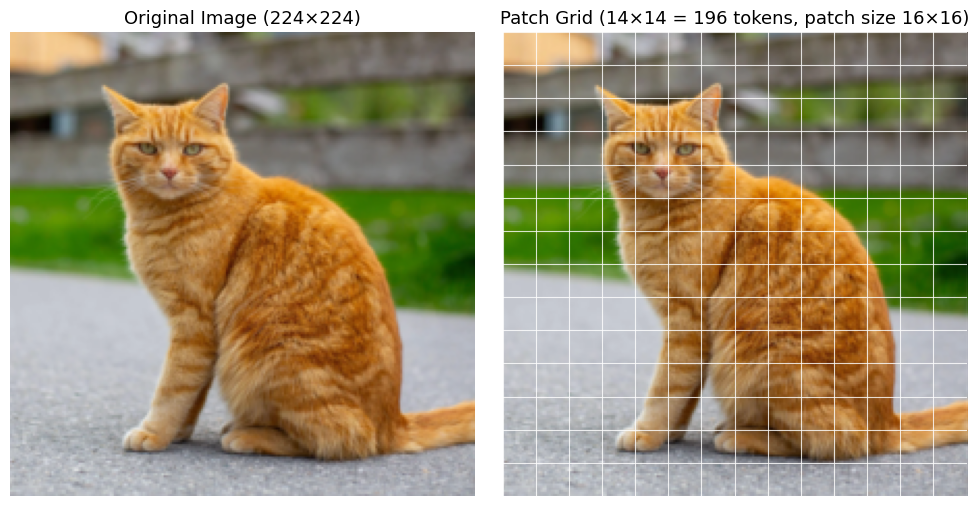

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_orig = Image.open(IMAGE_PATH).convert("RGB").resize((224, 224), Image.BILINEAR)
img_arr = np.array(img_orig)

patch_size = config.patch_size  # 16
num_patches_h = img_arr.shape[0] // patch_size  # 14
num_patches_w = img_arr.shape[1] // patch_size  # 14

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_arr)
axes[0].set_title("Original Image (224×224)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_arr)
for row in range(num_patches_h + 1):
    axes[1].axhline(row * patch_size - 0.5, color="white", linewidth=0.8, alpha=0.8)
for col in range(num_patches_w + 1):
    axes[1].axvline(col * patch_size - 0.5, color="white", linewidth=0.8, alpha=0.8)

axes[1].set_title(f"Patch Grid ({num_patches_h}×{num_patches_w} = {num_patches_h * num_patches_w} tokens, patch size {patch_size}×{patch_size})", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()
